# Modeling Histórico Chat

---

## Objetivo

O objetivo desse notebook é realizar análises exploratórias das features criadas até aqui e suas interações entre si, técnicas de Machine Learning para modelar linear e não linearmente a predição final, junto com benchmarks de modelos e resultado final.

---

## Código

---

### EDA

In [1]:
import pandas as pd

df_train = pd.read_parquet("../dados/processed/train.parquet")
df_test = pd.read_parquet("../dados/processed/test.parquet")

print("Primeiras linhas dados de treino")
print(df_train.head())
print("=" * 50)
print("Primeiras linhas dados de teste")
print(df_test.head())

Primeiras linhas dados de treino
                                  mensagem_embedding            dia  hora  \
0                  dois zagueiros e os dois volantes    Sexta-feira    15   
1                                            caralho  Segunda-feira    15   
2                                    ela deixou mano    Sexta-feira    21   
3  eu sinto que virei uma pessoa muito pior depoi...   Quinta-feira    19   
4                                              calma   Quarta-feira    11   

   qtd_caracteres  qtd_palavras  caracter_por_mensagem   membro  
0              33             6                  5.500     Luiz  
1               7             1                  7.000    André  
2              15             3                  5.000  Luquete  
3             117            24                  4.875  Luquete  
4               5             1                  5.000  Luquete  
Primeiras linhas dados de teste
                                  mensagem_embedding           dia  hora  \


In [6]:
import numpy as np

cluster_train_20k = np.load("../artifacts/clustering/clusters_train_20.npy")
cluster_test_20k = np.load("../artifacts/clustering/clusters_test_20.npy")

cluster_train_25k = np.load("../artifacts/clustering/clusters_train_25.npy")
cluster_test_25k = np.load("../artifacts/clustering/clusters_test_25.npy")

In [10]:
df_train["cluster_20"] = cluster_train_20k
df_test["cluster_20"]= cluster_test_20k

df_train["cluster_25"] = cluster_train_25k
df_test["cluster_25"]= cluster_test_25k

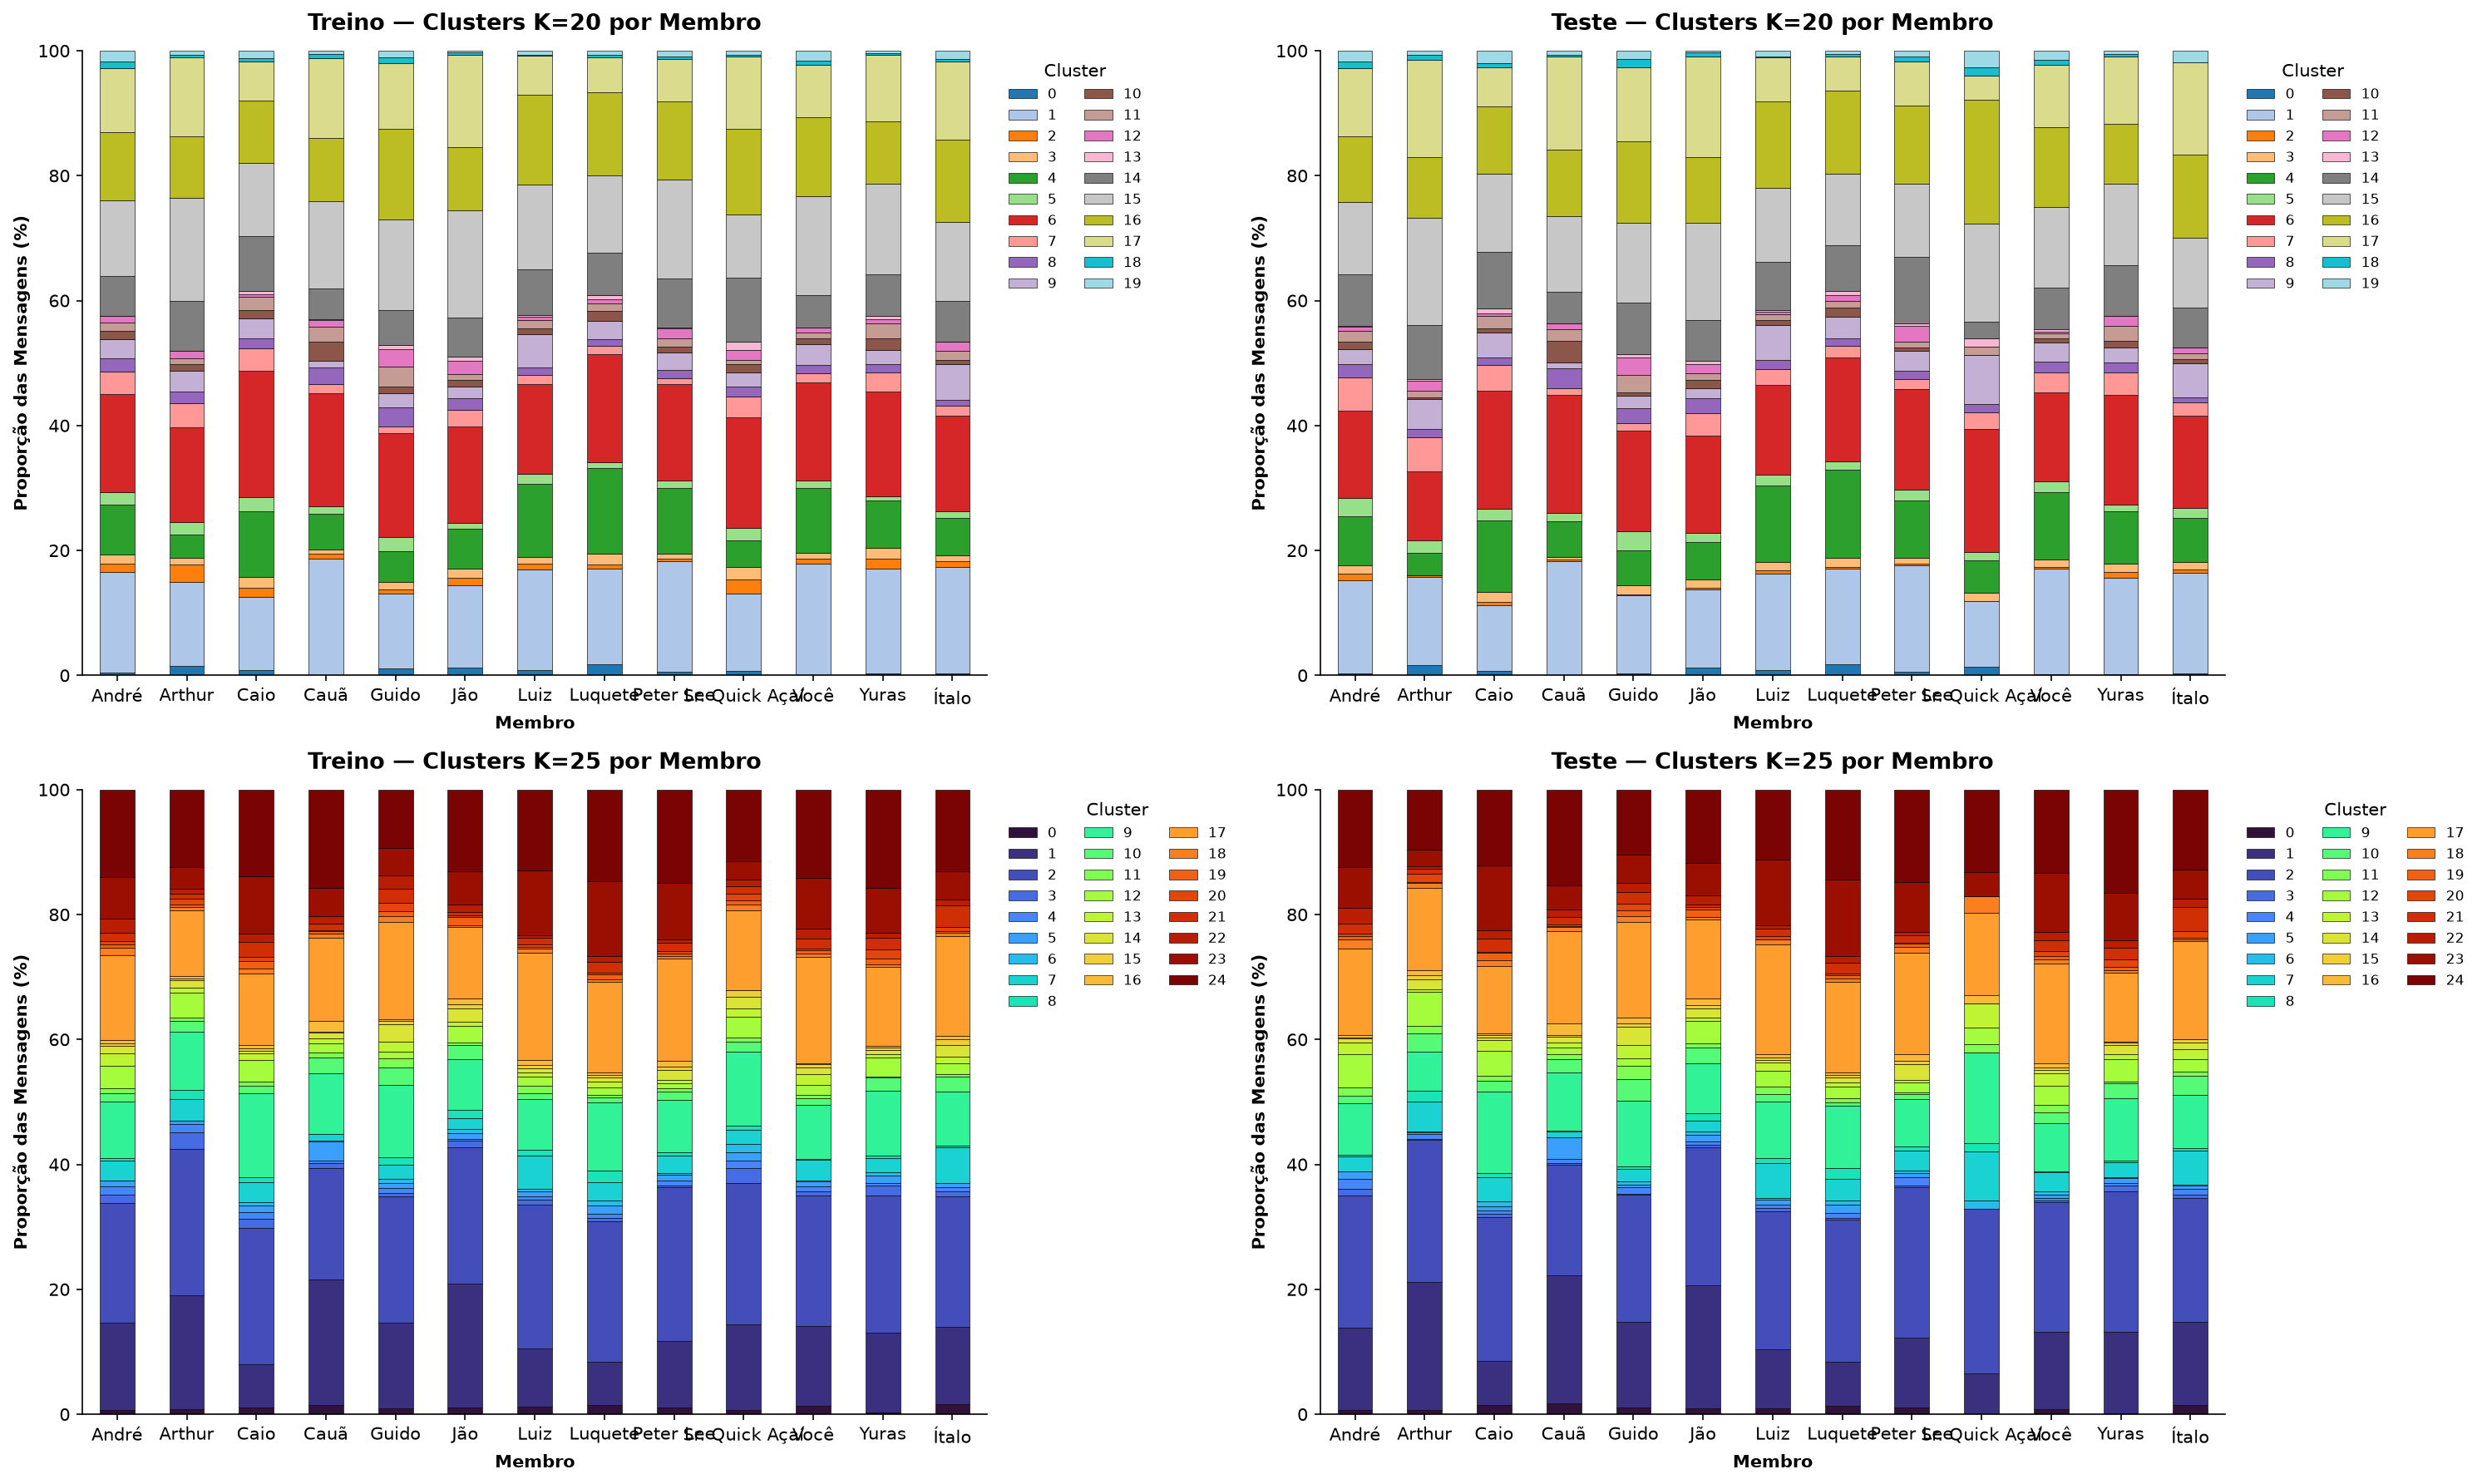

In [ ]:
import matplotlib.pyplot as plt
def get_cluster_member_prop(df, cluster_col):
    ct = pd.crosstab(df["membro"], df[cluster_col], normalize="index") * 100
    return ct


fig, axes = plt.subplots(2, 2, figsize=(20, 12), dpi=150)

configs = [
    (df_train, "cluster_20", axes[0, 0], "Treino — Clusters K=20 por Membro"),
    (df_test, "cluster_20", axes[0, 1], "Teste — Clusters K=20 por Membro"),
    (df_train, "cluster_25", axes[1, 0], "Treino — Clusters K=25 por Membro"),
    (df_test, "cluster_25", axes[1, 1], "Teste — Clusters K=25 por Membro"),
]

cmap_20 = plt.get_cmap("tab20", 20)
cmap_25 = plt.get_cmap("turbo", 25)

for df, col, ax, title in configs:
    prop_df = get_cluster_member_prop(df, col)

    k_num = int(col.split("_")[1])
    colors = (
        cmap_20(np.linspace(0, 1, 20))
        if k_num == 20
        else cmap_25(np.linspace(0, 1, 25))
    )

    prop_df.plot(
        kind="bar", stacked=True, ax=ax, color=colors, edgecolor="black", linewidth=0.3
    )

    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Membro", fontsize=10, fontweight="bold")
    ax.set_ylabel("Proporção das Mensagens (%)", fontsize=10, fontweight="bold")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=0)

    ncols = 2 if k_num == 20 else 3
    ax.legend(
        title="Cluster",
        bbox_to_anchor=(1.01, 1),
        loc="upper left",
        fontsize=8,
        ncol=ncols,
        frameon=False,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk

nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

pt_stopwords = stopwords.words('portuguese')

def extrair_top_termos_clusters(df, text_col, cluster_col, top_n=10):
    """
    Calcula as palavras mais representativas de cada cluster usando c-TF-IDF simplificado.
    """
    df_grouped = df.groupby(cluster_col)[text_col].apply(lambda texts: " ".join(texts.astype(str))).reset_index()
    
    vectorizer = TfidfVectorizer(
        max_df=0.7,         
        min_df=2,         
        stop_words=pt_stopwords,
        ngram_range=(1, 2)   
    )
    
    tfidf_matrix = vectorizer.fit_transform(df_grouped[text_col])
    feature_names = vectorizer.get_feature_names_out()
    
    top_terms_per_cluster = {}
    for idx, row in df_grouped.iterrows():
        cluster_id = row[cluster_col]
        scores = tfidf_matrix[idx].toarray().flatten()
        top_indices = scores.argsort()[-top_n:][::-1]
        top_words = [feature_names[i] for i in top_indices]
        top_terms_per_cluster[cluster_id] = top_words
        
    return pd.DataFrame(top_terms_per_cluster).T

def print_resumo_clusters(df_top_terms, nome_k):
    print(f"\n==================== RESUMO SEMÂNTICO ({nome_k}) ====================")
    for cluster_id, row in df_top_terms.iterrows():
        palavras = ", ".join(row.values)
        print(f"Cluster {cluster_id:2d} -> [{palavras}]")

top_k20 = extrair_top_termos_clusters(df_train, "mensagem_embedding", "cluster_20", top_n=8)
top_k25 = extrair_top_termos_clusters(df_train, "mensagem_embedding", "cluster_25", top_n=8)

/home/kau/Documentos/SCIA/venv/lib/python3.12/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/home/kau/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):


In [16]:
top_k20 = extrair_top_termos_clusters(df_train, "mensagem_embedding", "cluster_20", top_n=8)
top_k25 = extrair_top_termos_clusters(df_train, "mensagem_embedding", "cluster_25", top_n=8)

print_resumo_clusters(top_k20, "K=20")
print_resumo_clusters(top_k25, "K=25")


==================== RESUMO SEMÂNTICO (K=20) ====================
Cluster  0 -> [regular, daqui, to, falando gente, falando grupo, falando jogo, falando joão, falando mal]
Cluster  1 -> [mano, cara, pra, vai, vc, foda, tropa, aí]
Cluster  2 -> [bruh, quer dizer, dizer, quer, falando fez, falando gente, falando grupo, falando jogo]
Cluster  3 -> [calma, ok, beleza, ata, off, kkkkkkkkkkkkkkkkkkkk, kkkkkkkk, deus]
Cluster  4 -> [normal, mano, nada, nao, pior, nunca, vai, pra]
Cluster  5 -> [sim, sim sim, kkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkk, admin, kkkkkk, kkkkkk sim, kkkkkkkkkkkkkkkkkkkkkkkkkk, kkkkkkkkkkkkkkkkkkkkkkkk]
Cluster  6 -> [pra, vai, dia, casa, jogo, vou, mano, fifa]
Cluster  7 -> [encaminhada, encaminhada muitas, muitas vezes, muitas, vezes, vezes encaminhada, jão, vai]
Cluster  8 -> [pqp, album, kkkkkkkkkkkkkkkk, blz, slk, porra, kkkkkkkkkkkkkkkkkkk, cara]
Cluster  9 -> [luquete, kau, jão, caio, luiz, andré, ítalo, yuras]
Cluster 10 -> [brasil, argentina, ata, grupo

In [17]:
from sklearn.metrics import mutual_info_score

mi_20 = mutual_info_score(
    df_train["membro"],
    df_train["cluster_20"]
)

mi_25 = mutual_info_score(
    df_train["membro"],
    df_train["cluster_25"]
)

print("MI K=20:", mi_20)
print("MI K=25:", mi_25)

MI K=20: 0.03289420372915088
MI K=25: 0.04050409861952314


In [27]:
from scipy import sparse 

embedding_train = np.load("../artifacts/embedding/embeddings_train.npy")
embedding_test = np.load("../artifacts/embedding/embeddings_test.npy")

tfidf_train = sparse.load_npz("../artifacts/tfidf/tfidf_train.npz")
tfidf_test = sparse.load_npz("../artifacts/tfidf/tfidf_test.npz")

In [36]:
print(f"Número de linhas dataset treino: {df_train.shape[0]}")
print("=" * 50)
print(f"Número de linhas embeddings treino: {embedding_train.shape[0]}")
print("=" * 50)
print(f"Número de linhas TF-IDF treino: {tfidf_train.shape[0]}")
print("=" * 50 + "\n" * 3)

print(f"Número de linhas dataset teste: {df_test.shape[0]}")
print("=" * 50)
print(f"Número de linhas embeddings teste: {embedding_test.shape[0]}")
print("=" * 50)
print(f"Número de linhas TF-IDF teste: {tfidf_test.shape[0]}")
print("=" * 50 + "\n")

Número de linhas dataset treino: 78955
Número de linhas embeddings treino: 78955
Número de linhas TF-IDF treino: 78955



Número de linhas dataset teste: 19739
Número de linhas embeddings teste: 19739
Número de linhas TF-IDF teste: 19739



### Feature Engineering

In [44]:
df_train["hora_sin"] = np.sin(2 * np.pi * df_train["hora"] / 24)
df_train["hora_cos"] = np.cos(2 * np.pi * df_train["hora"] / 24)
hora_sin_train = df_train["hora_sin"].values.reshape(-1, 1)
hora_cos_train = df_train["hora_cos"].values.reshape(-1, 1)
df_dia_dummies_train = pd.get_dummies(df_train["dia"], prefix="dia", drop_first=True, dtype=float)
dia_dummies_array_train = df_dia_dummies_train.to_numpy()
char_per_msg_train = df_train["caracter_por_mensagem"].to_numpy().reshape(-1, 1)
df_cluster20_dummies_train = pd.get_dummies(df_train["cluster_20"], prefix="cluster_20", drop_first=True, dtype=float)
df_cluster25_dummies_train = pd.get_dummies(df_train["cluster_25"], prefix="cluster_25", drop_first=True, dtype=float)
cluster20_dummies_array_train = df_cluster20_dummies_train.to_numpy()
cluster25_dummies_array_train = df_cluster25_dummies_train.to_numpy()


df_test["hora_sin"] = np.sin(2 * np.pi * df_test["hora"] / 24)
df_test["hora_cos"] = np.cos(2 * np.pi * df_test["hora"] / 24)
hora_sin_test = df_test["hora_sin"].values.reshape(-1, 1)
hora_cos_test = df_test["hora_cos"].values.reshape(-1, 1)
df_dia_dummies_test = pd.get_dummies(df_test["dia"], prefix="dia", drop_first=True, dtype=float)
df_dia_dummies_test = df_dia_dummies_test.reindex(
    columns=df_dia_dummies_train.columns,
    fill_value=0
)
dia_dummies_array_test = df_dia_dummies_test.to_numpy()
char_per_msg_test = df_test["caracter_por_mensagem"].to_numpy().reshape(-1, 1)
df_cluster20_dummies_test = pd.get_dummies(df_test["cluster_20"], prefix="cluster_20", drop_first=True, dtype=float)
df_cluster20_dummies_test = df_cluster20_dummies_test.reindex(
    columns=df_cluster20_dummies_train.columns,
    fill_value=0
)
df_cluster25_dummies_test = pd.get_dummies(df_test["cluster_25"], prefix="cluster_25", drop_first=True, dtype=float)
df_cluster25_dummies_test = df_cluster25_dummies_test.reindex(
    columns=df_cluster25_dummies_train.columns,
    fill_value=0
)
cluster20_dummies_array_test = df_cluster20_dummies_test.to_numpy()
cluster25_dummies_array_test = df_cluster25_dummies_test.to_numpy()

In [45]:
import scipy.sparse as sp

X_train_20 = sp.hstack([
    hora_sin_train,
    hora_cos_train,
    dia_dummies_array_train,
    char_per_msg_train,
    cluster20_dummies_array_train,
    embedding_train,
    tfidf_train
]).tocsr()

X_test_20 = sp.hstack([
    hora_sin_test,
    hora_cos_test,
    dia_dummies_array_test,
    char_per_msg_test,
    cluster20_dummies_array_test,
    embedding_test,
    tfidf_test
]).tocsr()

X_train_25 = sp.hstack([
    hora_sin_train,
    hora_cos_train,
    dia_dummies_array_train,
    char_per_msg_train,
    cluster25_dummies_array_train,
    embedding_train,
    tfidf_train
]).tocsr()

X_test_25 = sp.hstack([
    hora_sin_test,
    hora_cos_test,
    dia_dummies_array_test,
    char_per_msg_test,
    cluster25_dummies_array_test,
    embedding_test,
    tfidf_test
]).tocsr()

y_train = df_train["membro"]
y_test = df_test["membro"]

### Modeling

/home/kau/Documentos/SCIA/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/home/kau/Documentos/SCIA/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


==============================REPORT 20 CLUSTERS==============================
                precision    recall  f1-score   support

         André       0.29      0.19      0.23      1896
        Arthur       0.07      0.23      0.11       481
          Caio       0.31      0.31      0.31      1342
          Cauã       0.30      0.38      0.34      1221
         Guido       0.31      0.39      0.35      1160
           Jão       0.25      0.27      0.26      1523
          Luiz       0.42      0.24      0.31      2526
       Luquete       0.52      0.27      0.35      4124
     Peter Lee       0.15      0.17      0.16       950
Sr. Quick Açaí       0.02      0.18      0.03        76
          Você       0.23      0.29      0.26      1419
         Yuras       0.24      0.29      0.26      1327
         Ítalo       0.29      0.34      0.31      1694

      accuracy                           0.28     19739
     macro avg       0.26      0.27      0.25     19739
  weighted avg       0.

/home/kau/Documentos/SCIA/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/home/kau/Documentos/SCIA/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


==============================REPORT 25 CLUSTERS==============================
                precision    recall  f1-score   support

         André       0.30      0.17      0.22      1896
        Arthur       0.08      0.20      0.11       481
          Caio       0.28      0.37      0.31      1342
          Cauã       0.31      0.41      0.36      1221
         Guido       0.31      0.42      0.36      1160
           Jão       0.27      0.24      0.25      1523
          Luiz       0.38      0.26      0.31      2526
       Luquete       0.52      0.25      0.34      4124
     Peter Lee       0.13      0.20      0.16       950
Sr. Quick Açaí       0.02      0.22      0.03        76
          Você       0.25      0.30      0.28      1419
         Yuras       0.26      0.28      0.27      1327
         Ítalo       0.31      0.33      0.32      1694

      accuracy                           0.28     19739
     macro avg       0.26      0.28      0.25     19739
  weighted avg       0.

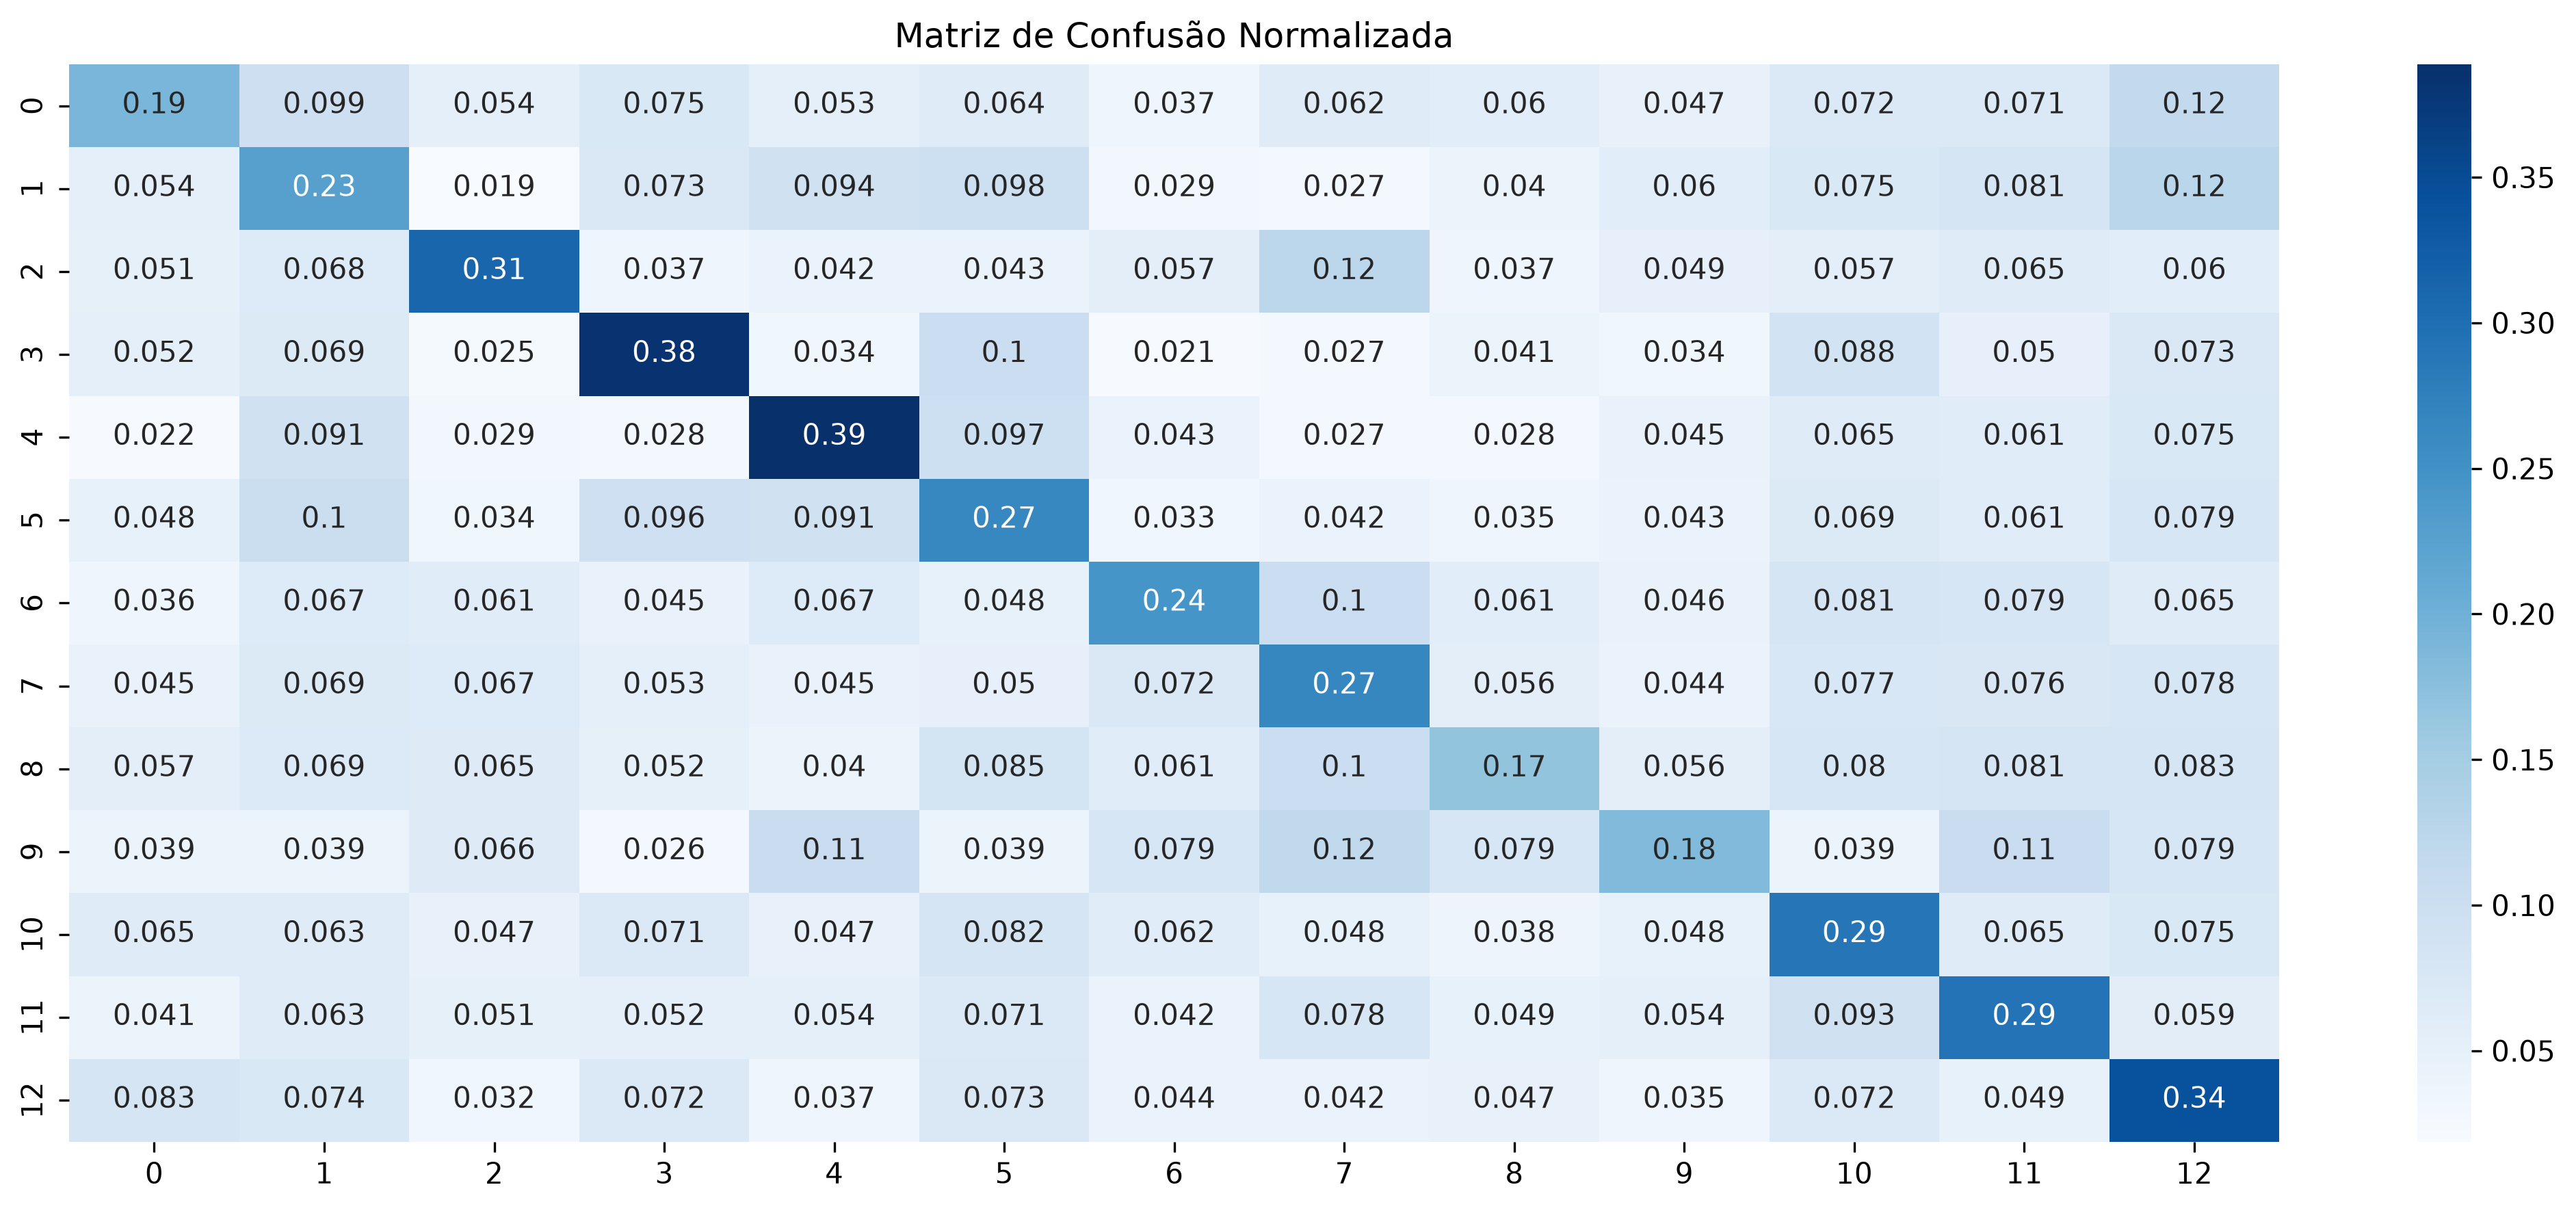

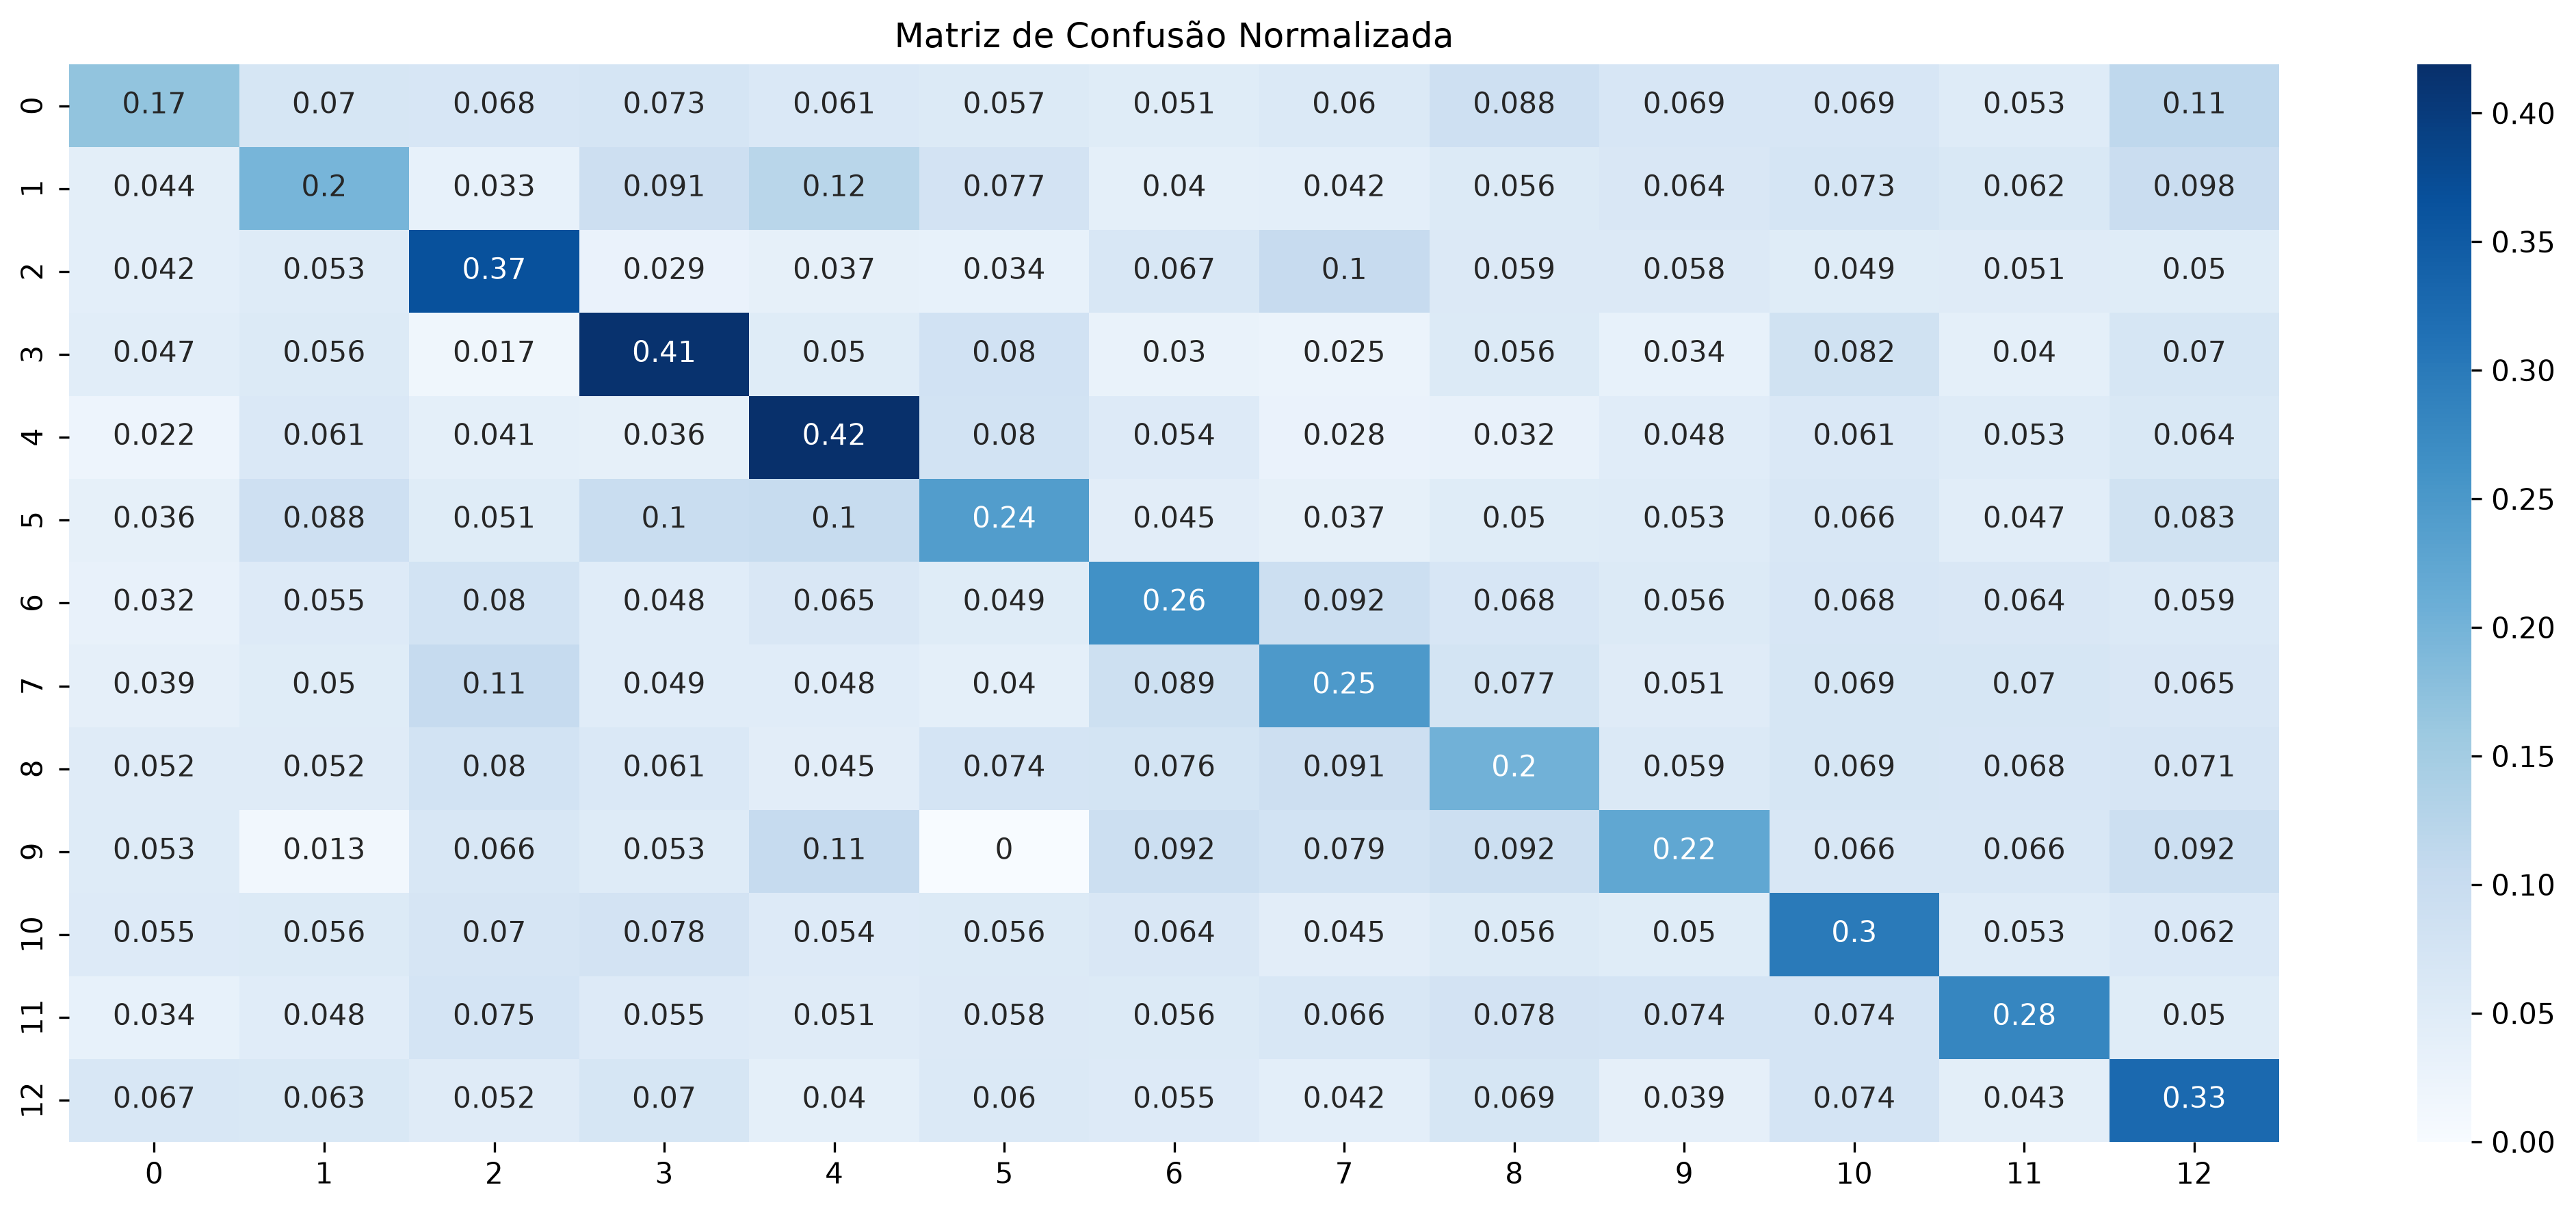

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

clf = LogisticRegression(max_iter=1_000, class_weight="balanced", C=1.0, n_jobs=-1)

clf.fit(X_train_20, y_train)

y_pred20 = clf.predict(X_test_20)

print("=" * 30 + "REPORT 20 CLUSTERS" + "=" * 30)

print(classification_report(y_test, y_pred20, zero_division=0))

plt.figure(figsize=(14, 6), dpi=300)

sns.heatmap(confusion_matrix(y_test, y_pred20, normalize="true"), annot=True, cmap="Blues")

plt.title("Matriz de Confusão Normalizada")
plt.tight_layout()

print("\n" * 10)

clf.fit(X_train_25, y_train)

y_pred25 = clf.predict(X_test_25)

print("=" * 30 + "REPORT 25 CLUSTERS" + "=" * 30)

print(classification_report(y_test, y_pred25, zero_division=0))

plt.figure(figsize=(14, 6), dpi=300)

sns.heatmap(confusion_matrix(y_test, y_pred25, normalize="true"), annot=True, cmap="Blues")

plt.title("Matriz de Confusão Normalizada")
plt.tight_layout()

In [48]:
import copy
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import LabelEncoder

class SparseDataset(Dataset):
    def __init__(self, X_sparse, y_encoded):
        self.X_sparse = X_sparse.tocsr()
        self.y = torch.tensor(y_encoded, dtype=torch.long)

    def __len__(self):
        return self.X_sparse.shape[0]

    def __getitem__(self, idx):
        x_sample = self.X_sparse[idx].toarray().squeeze(0)

        return (
            torch.tensor(x_sample, dtype=torch.float32),
            self.y[idx]
        )

class SparseMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)

le = LabelEncoder()
y_tr_enc = le.fit_transform(y_train)
y_te_enc = le.transform(y_test)

num_classes = len(le.classes_)

class_counts = np.bincount(y_tr_enc)
total_samples = len(y_tr_enc)
class_weights = total_samples / (num_classes * class_counts)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

def train_and_eval_mlp(
    X_tr,
    y_tr,
    X_te,
    y_te,
    name="MLP",
    epochs=20,
    batch_size=256,
    lr=0.001
):

    # =========================
    # Train / validation split
    # =========================

    idx_train, idx_val = train_test_split(
        np.arange(len(y_tr)),
        test_size=0.1,
        stratify=y_tr,
        random_state=42
    )

    full_train_dataset = SparseDataset(X_tr, y_tr)

    train_dataset = Subset(
        full_train_dataset,
        idx_train
    )

    val_dataset = Subset(
        full_train_dataset,
        idx_val
    )

    test_dataset = SparseDataset(X_te, y_te)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True if device.type == "cuda" else False
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    # =========================
    # Model
    # =========================

    model = SparseMLP(
        X_tr.shape[1],
        num_classes
    ).to(device)

    criterion = nn.CrossEntropyLoss(
        weight=weights_tensor
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    # =========================
    # Early stopping
    # =========================

    best_val_f1 = 0.0
    patience = 4
    patience_counter = 0

    best_model_weights = None

    print(
        f"\n==================== "
        f"Treinando {name} "
        f"===================="
    )

    for epoch in range(1, epochs + 1):

        # ---------------------
        # TRAIN
        # ---------------------

        model.train()

        running_loss = 0.0

        for inputs, targets in train_loader:

            inputs = inputs.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(
                outputs,
                targets
            )

            loss.backward()
            optimizer.step()

            running_loss += (
                loss.item() * inputs.size(0)
            )

        train_loss = (
            running_loss /
            len(train_dataset)
        )

        # ---------------------
        # VALIDATION
        # ---------------------

        model.eval()

        val_preds = []
        val_targets = []

        with torch.no_grad():

            for inputs, targets in val_loader:

                inputs = inputs.to(device)

                outputs = model(inputs)

                preds = (
                    torch.argmax(
                        outputs,
                        dim=1
                    )
                    .cpu()
                    .numpy()
                )

                val_preds.extend(preds)
                val_targets.extend(
                    targets.numpy()
                )

        val_f1 = f1_score(
            val_targets,
            val_preds,
            average="macro"
        )

        print(
            f"Epoch {epoch:02d}/{epochs:02d} "
            f"| Train Loss: {train_loss:.4f} "
            f"| Val F1 Macro: {val_f1:.4f}"
        )

        # ---------------------
        # EARLY STOPPING
        # ---------------------

        if val_f1 > best_val_f1:

            best_val_f1 = val_f1
            patience_counter = 0

            best_model_weights = copy.deepcopy(
                model.state_dict()
            )

        else:

            patience_counter += 1

            if patience_counter >= patience:

                print(
                    f"Early stopping acionado "
                    f"na época {epoch}!"
                )

                break

    # Recupera melhor modelo
    model.load_state_dict(
        best_model_weights
    )

    # =========================
    # FINAL TEST
    # =========================

    model.eval()

    test_preds = []
    test_targets = []

    with torch.no_grad():

        for inputs, targets in test_loader:

            inputs = inputs.to(device)

            outputs = model(inputs)

            preds = (
                torch.argmax(
                    outputs,
                    dim=1
                )
                .cpu()
                .numpy()
            )

            test_preds.extend(preds)
            test_targets.extend(
                targets.numpy()
            )

    test_f1 = f1_score(
        test_targets,
        test_preds,
        average="macro"
    )

    print(
        f"\n{name} | "
        f"Best Val F1: {best_val_f1:.4f} | "
        f"Test F1 Macro: {test_f1:.4f}"
    )

    return (
        model,
        best_val_f1,
        test_f1,
        np.array(test_preds),
        np.array(test_targets)
    )

In [49]:
# 1. Executar no K=20
model_20, val_f1_20, test_f1_20, preds_20, targets_20 = train_and_eval_mlp(
    X_train_20, y_tr_enc, X_test_20, y_te_enc, name="MLP (Clusters K=20)"
)

# 2. Executar no K=25
model_25, val_f1_25, test_f1_25, preds_25, targets_25 = train_and_eval_mlp(
    X_train_25, y_tr_enc, X_test_25, y_te_enc, name="MLP (Clusters K=25)"
)

print("\n==================== VEREDITO FINAL ====================")
print(f"F1 Macro (K=20): {val_f1_20:.4f}")
print(f"F1 Macro (K=25): {val_f1_25:.4f}")

if val_f1_25 > val_f1_20:
    print("-> A featurização com 25 Clusters superou a de 20 Clusters!")
    best_preds = preds_25
else:
    print("-> A featurização com 20 Clusters superou a de 25 Clusters!")
    best_preds = preds_20

print("\nRelatório Detalhado por Membro (Melhor Modelo):")
print(classification_report(y_te_enc, best_preds, target_names=le.classes_))


==================== Treinando MLP (Clusters K=20) ====================
Epoch 01/20 | Train Loss: 2.4115 | Val F1 Macro: 0.2068
Epoch 02/20 | Train Loss: 2.0570 | Val F1 Macro: 0.2643
Epoch 03/20 | Train Loss: 1.7166 | Val F1 Macro: 0.2865
Epoch 04/20 | Train Loss: 1.4358 | Val F1 Macro: 0.2905
Epoch 05/20 | Train Loss: 1.2220 | Val F1 Macro: 0.2978
Epoch 06/20 | Train Loss: 1.0527 | Val F1 Macro: 0.2995
Epoch 07/20 | Train Loss: 0.9329 | Val F1 Macro: 0.2950
Epoch 08/20 | Train Loss: 0.8495 | Val F1 Macro: 0.2964
Epoch 09/20 | Train Loss: 0.7819 | Val F1 Macro: 0.2963
Epoch 10/20 | Train Loss: 0.7333 | Val F1 Macro: 0.2977
Early stopping acionado na época 10!

MLP (Clusters K=20) | Best Val F1: 0.2995 | Test F1 Macro: 0.2989

==================== Treinando MLP (Clusters K=25) ====================
Epoch 01/20 | Train Loss: 2.4269 | Val F1 Macro: 0.2036
Epoch 02/20 | Train Loss: 2.0792 | Val F1 Macro: 0.2730
Epoch 03/20 | Train Loss: 1.7501 | Val F1 Macro: 0.2850
Epoch 04/20 | Train Lo

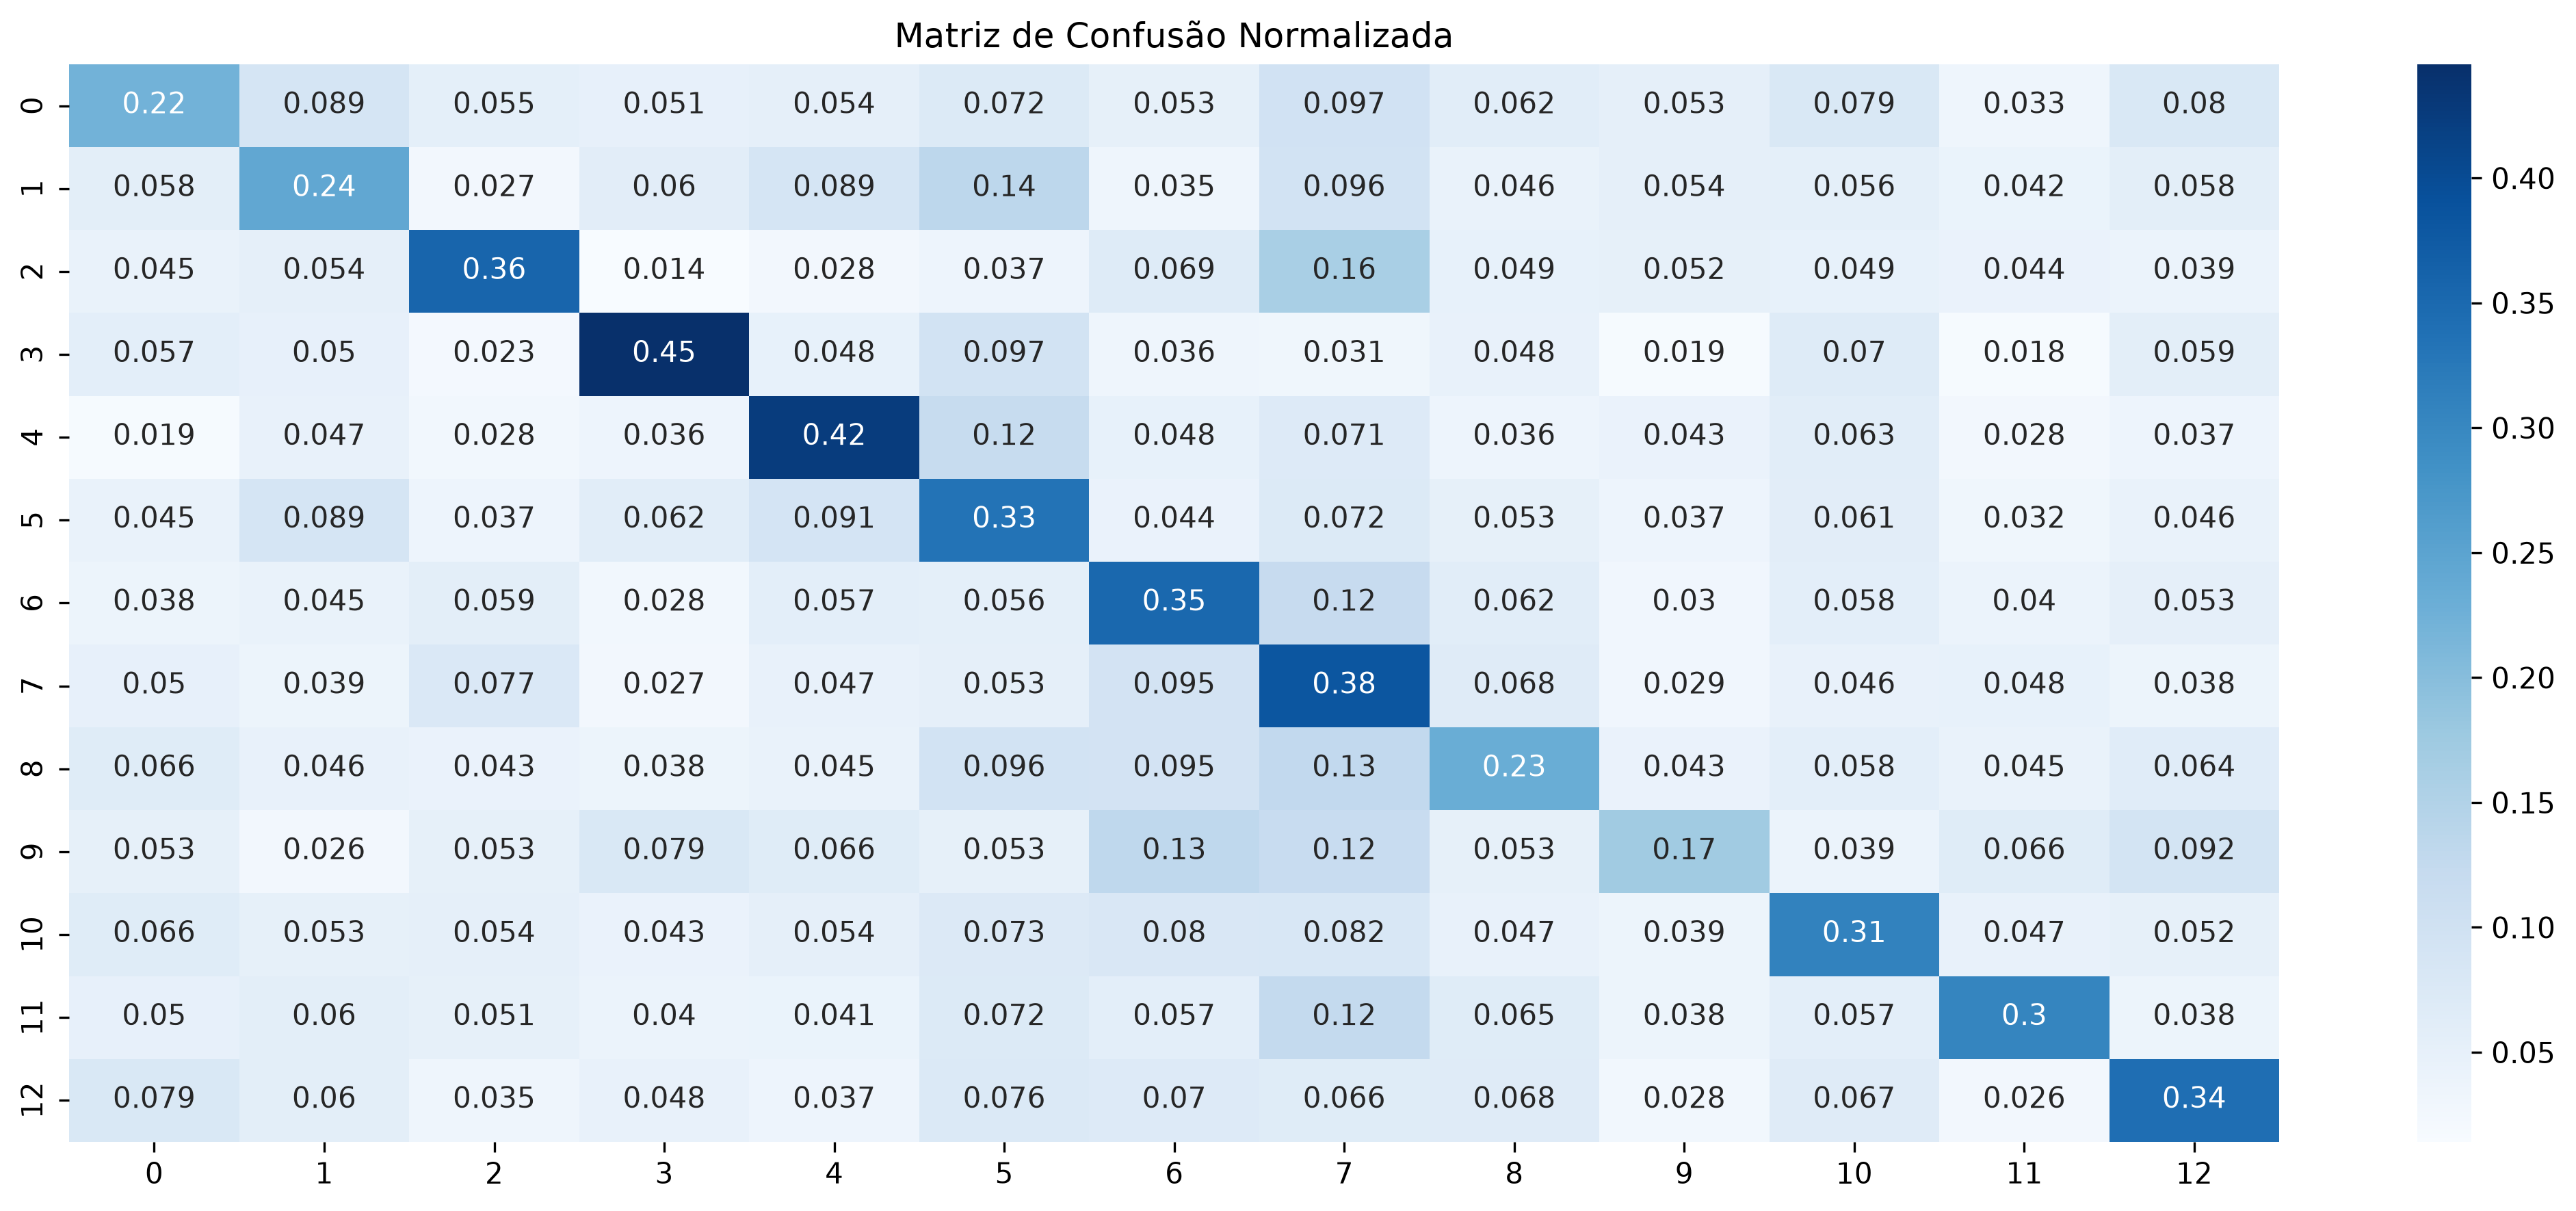

In [50]:
plt.figure(figsize=(14, 6), dpi=300)

sns.heatmap(confusion_matrix(y_te_enc, best_preds, normalize="true"), annot=True, cmap="Blues")

plt.title("Matriz de Confusão Normalizada")
plt.tight_layout()

Em relação à regressão logística, o MLP apresentou aumento de 0,25 para 0,30 no Macro F1, correspondendo a um ganho absoluto de 0,05 ponto e relativo de aproximadamente 20%.

Não houve muita diferença entre os K-clusters, de 20 e 25, porém, com um ganho mínimo de eficiência, os 25 clusters foram melhores.

Agora, vamos tentar três ablações:
 - Sem os Clusters;
 - Sem os Embeddings;
 - Sem os Clusters e Embeddings.

In [53]:
X_train_no_cluster = sp.hstack([
    hora_sin_train,
    hora_cos_train,
    dia_dummies_array_train,
    char_per_msg_train,
    embedding_train,
    tfidf_train
]).tocsr()

X_test_no_cluster = sp.hstack([
    hora_sin_test,
    hora_cos_test,
    dia_dummies_array_test,
    char_per_msg_test,
    embedding_test,
    tfidf_test
]).tocsr()

In [55]:
model_no_cluster, val_f1_no_cluster, test_f1_no_cluster, preds_no_cluster, targets_no_cluster = train_and_eval_mlp(
    X_train_no_cluster, y_tr_enc, X_test_no_cluster, y_te_enc, name="MLP (No Clusters)"
)

print("\n==================== VEREDITO FINAL ====================")
print(f"F1 Macro: {val_f1_no_cluster:.4f}")

print("\nRelatório Detalhado por Membro:")
print(classification_report(y_te_enc, preds_no_cluster, target_names=le.classes_))


==================== Treinando MLP (No Clusters) ====================
Epoch 01/20 | Train Loss: 2.4223 | Val F1 Macro: 0.2190
Epoch 02/20 | Train Loss: 2.0710 | Val F1 Macro: 0.2661
Epoch 03/20 | Train Loss: 1.7493 | Val F1 Macro: 0.2881
Epoch 04/20 | Train Loss: 1.4699 | Val F1 Macro: 0.2869
Epoch 05/20 | Train Loss: 1.2515 | Val F1 Macro: 0.2913
Epoch 06/20 | Train Loss: 1.0819 | Val F1 Macro: 0.2939
Epoch 07/20 | Train Loss: 0.9581 | Val F1 Macro: 0.2995
Epoch 08/20 | Train Loss: 0.8717 | Val F1 Macro: 0.2978
Epoch 09/20 | Train Loss: 0.8007 | Val F1 Macro: 0.2965
Epoch 10/20 | Train Loss: 0.7450 | Val F1 Macro: 0.2938
Epoch 11/20 | Train Loss: 0.7068 | Val F1 Macro: 0.2957
Early stopping acionado na época 11!

MLP (No Clusters) | Best Val F1: 0.2995 | Test F1 Macro: 0.2963

==================== VEREDITO FINAL ====================
F1 Macro: 0.2995

Relatório Detalhado por Membro:
                precision    recall  f1-score   support

         André       0.29      0.26      0.28 

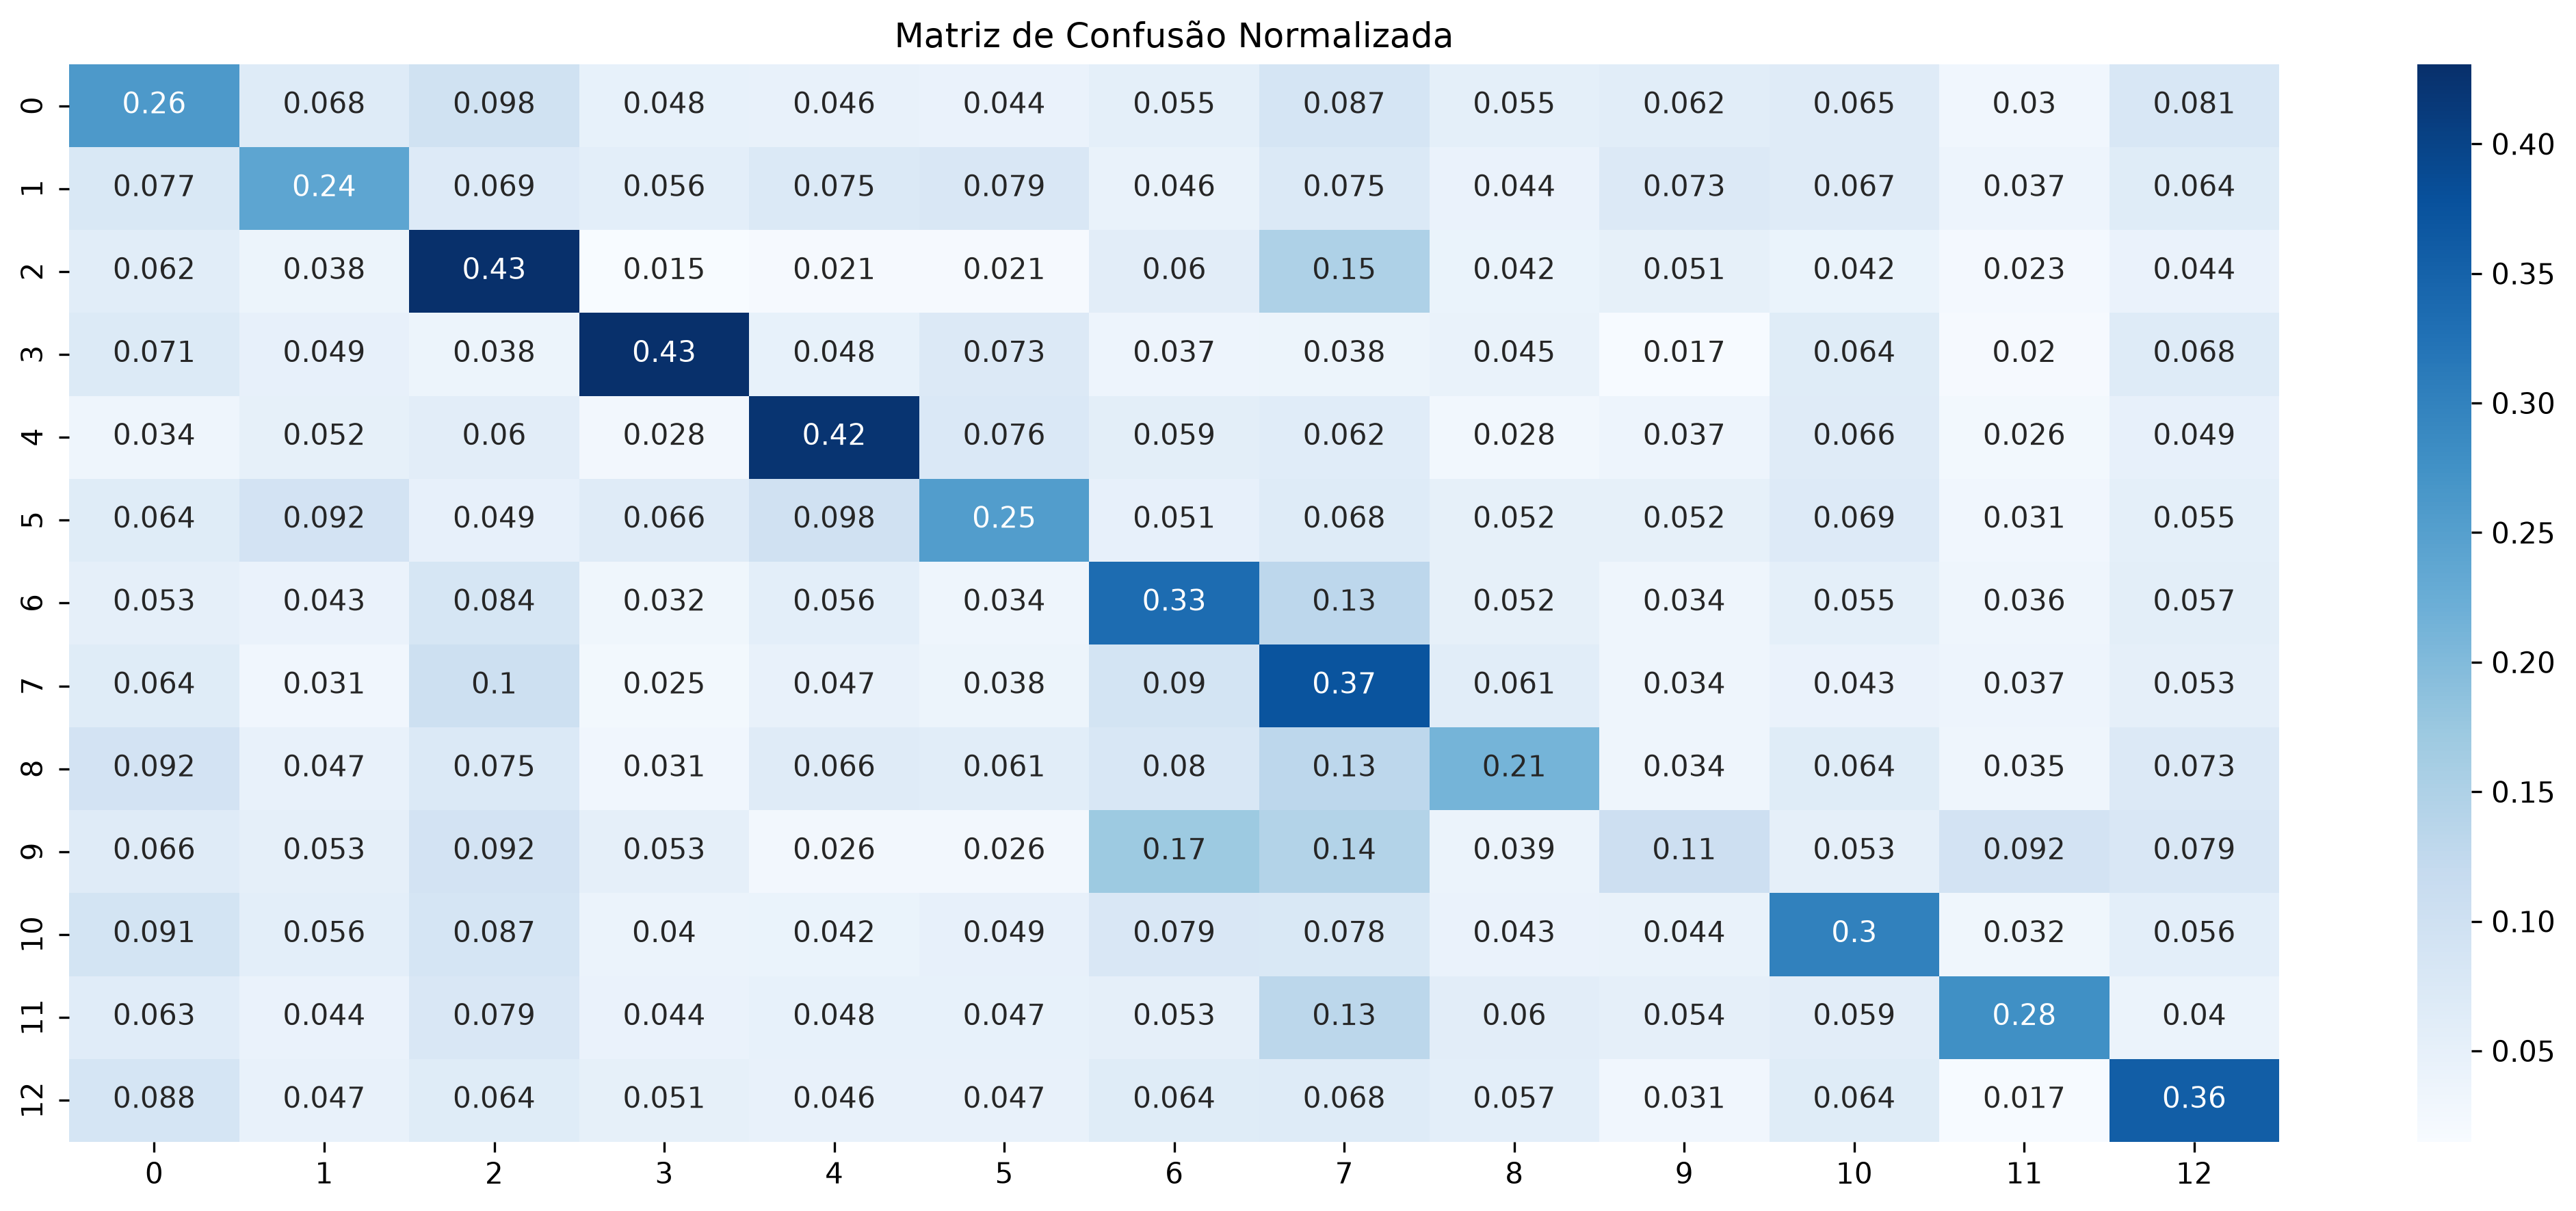

In [56]:
plt.figure(figsize=(14, 6), dpi=300)

sns.heatmap(confusion_matrix(y_te_enc, preds_no_cluster, normalize="true"), annot=True, cmap="Blues")

plt.title("Matriz de Confusão Normalizada")
plt.tight_layout()

In [57]:
X_train_no_emb = sp.hstack([
    hora_sin_train,
    hora_cos_train,
    dia_dummies_array_train,
    cluster25_dummies_array_train,
    char_per_msg_train,
    tfidf_train
]).tocsr()

X_test_no_emb = sp.hstack([
    hora_sin_test,
    hora_cos_test,
    dia_dummies_array_test,
    cluster25_dummies_array_test,
    char_per_msg_test,
    tfidf_test
]).tocsr()

In [58]:
model_no_emb, val_f1_no_emb, test_f1_no_emb, preds_no_emb, targets_no_emb = train_and_eval_mlp(
    X_train_no_emb, y_tr_enc, X_test_no_emb, y_te_enc, name="MLP (No Embeddings)"
)

print("\n==================== VEREDITO FINAL ====================")
print(f"F1 Macro: {val_f1_no_emb:.4f}")

print("\nRelatório Detalhado por Membro:")
print(classification_report(y_te_enc, preds_no_emb, target_names=le.classes_))


==================== Treinando MLP (No Embeddings) ====================
Epoch 01/20 | Train Loss: 2.4351 | Val F1 Macro: 0.2080
Epoch 02/20 | Train Loss: 2.0642 | Val F1 Macro: 0.2756
Epoch 03/20 | Train Loss: 1.7205 | Val F1 Macro: 0.2904
Epoch 04/20 | Train Loss: 1.4262 | Val F1 Macro: 0.2889
Epoch 05/20 | Train Loss: 1.1971 | Val F1 Macro: 0.2945
Epoch 06/20 | Train Loss: 1.0358 | Val F1 Macro: 0.2946
Epoch 07/20 | Train Loss: 0.9062 | Val F1 Macro: 0.3016
Epoch 08/20 | Train Loss: 0.8176 | Val F1 Macro: 0.2958
Epoch 09/20 | Train Loss: 0.7535 | Val F1 Macro: 0.2925
Epoch 10/20 | Train Loss: 0.7074 | Val F1 Macro: 0.2926
Epoch 11/20 | Train Loss: 0.6620 | Val F1 Macro: 0.2884
Early stopping acionado na época 11!

MLP (No Embeddings) | Best Val F1: 0.3016 | Test F1 Macro: 0.2991

==================== VEREDITO FINAL ====================
F1 Macro: 0.3016

Relatório Detalhado por Membro:
                precision    recall  f1-score   support

         André       0.27      0.28      0

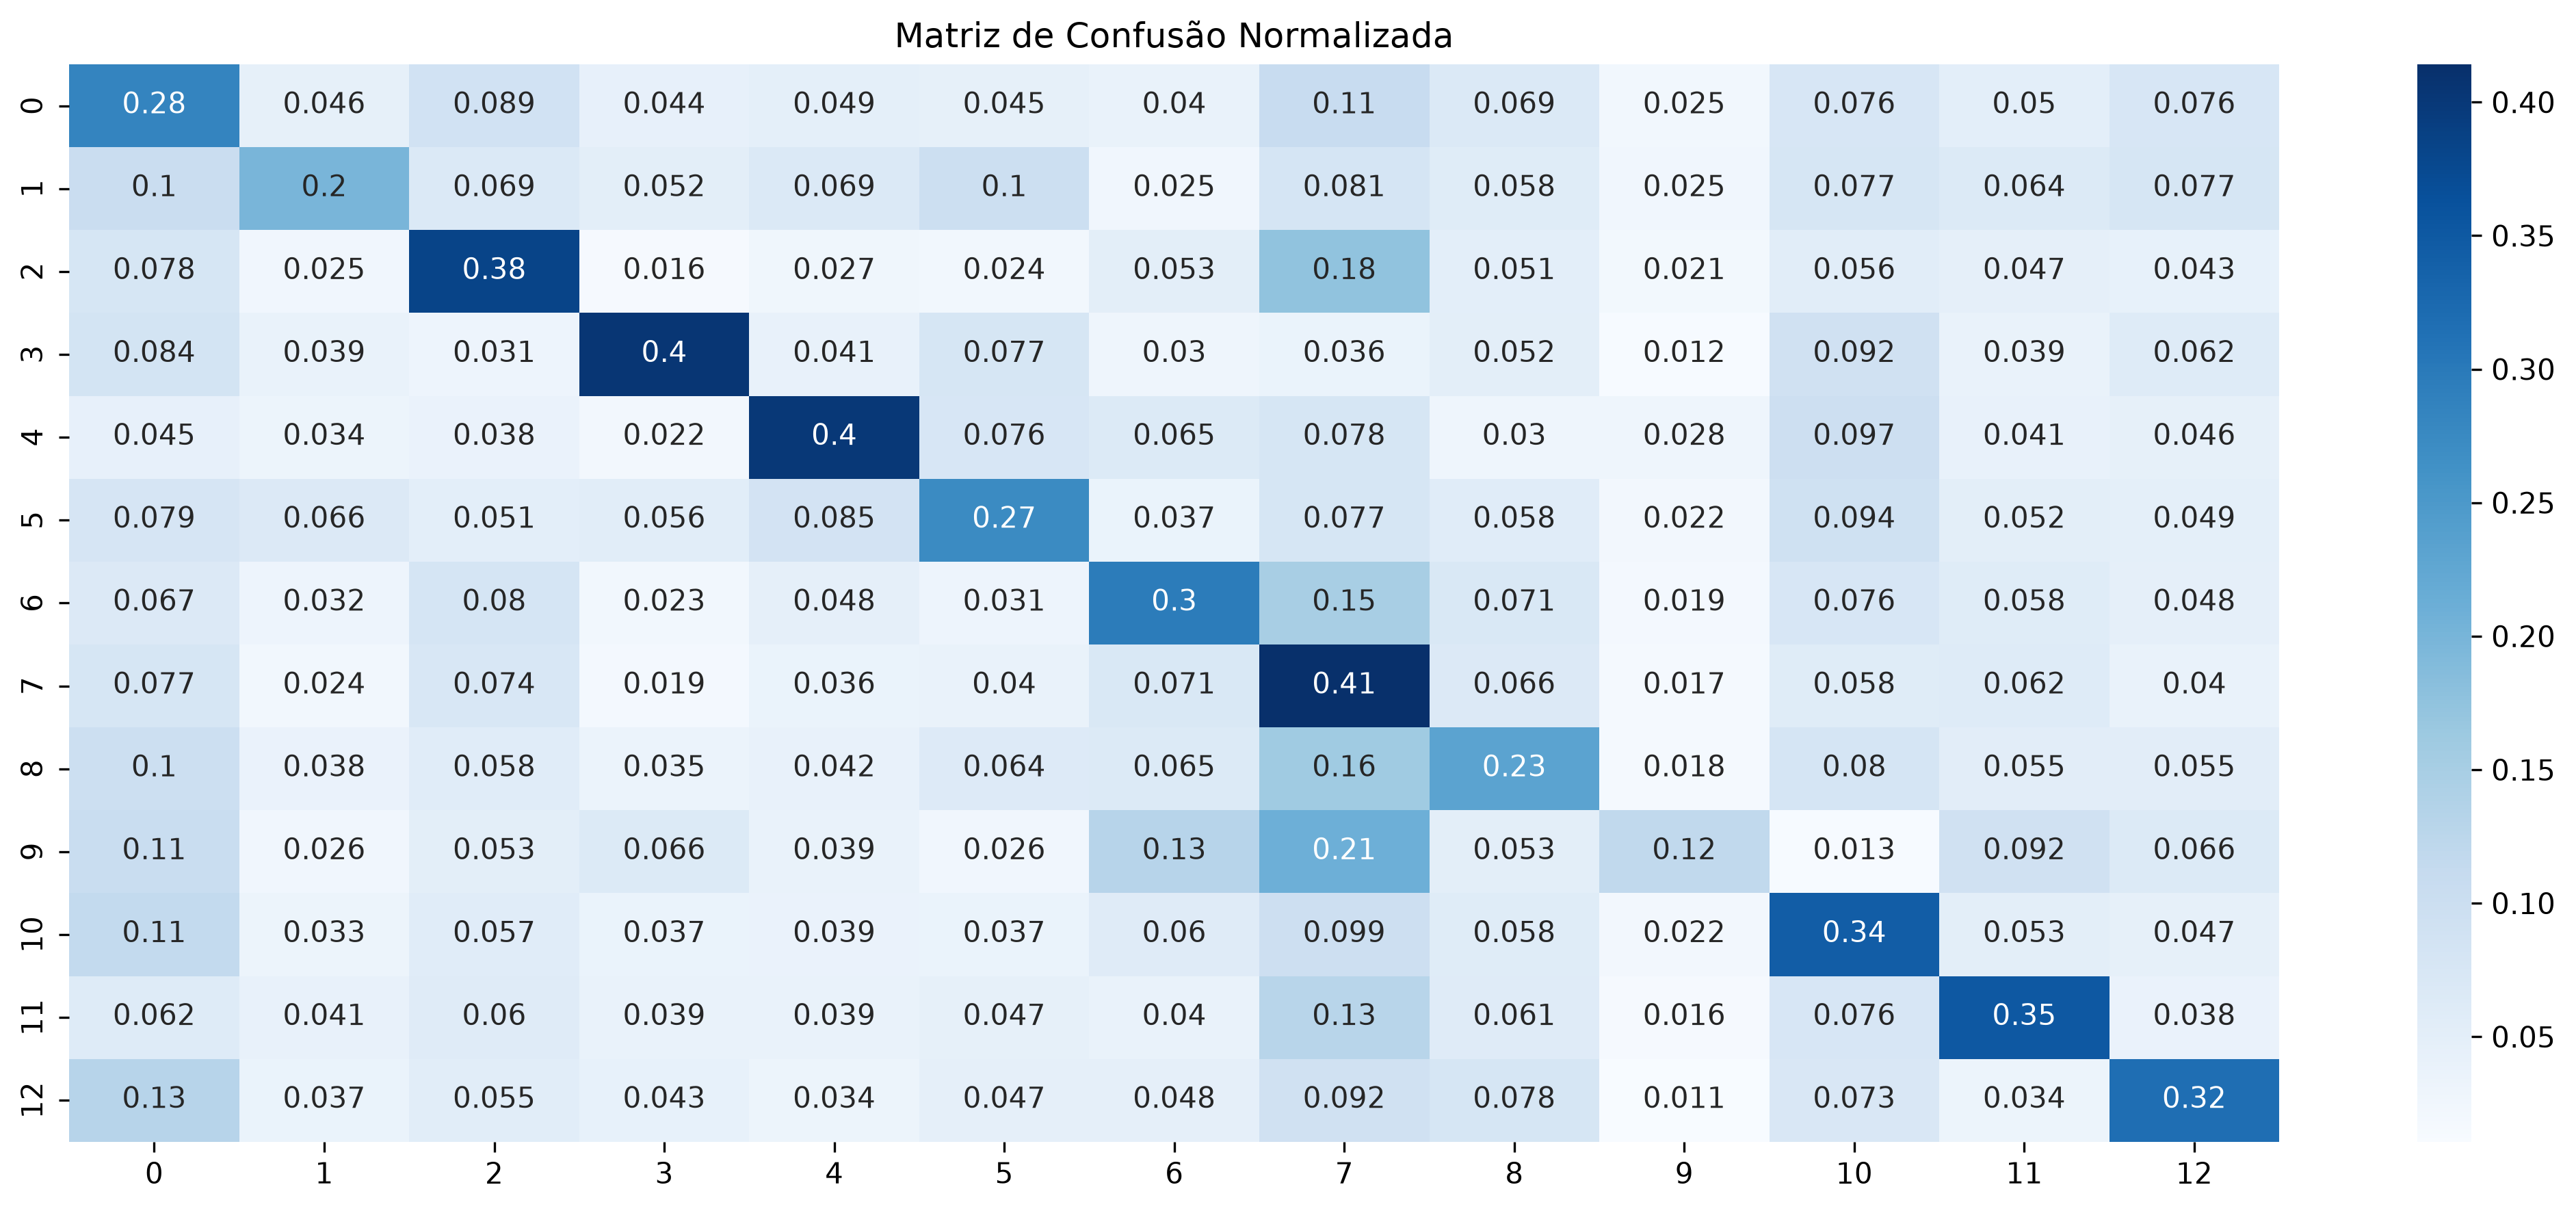

In [59]:
plt.figure(figsize=(14, 6), dpi=300)

sns.heatmap(confusion_matrix(y_te_enc, preds_no_emb, normalize="true"), annot=True, cmap="Blues")

plt.title("Matriz de Confusão Normalizada")
plt.tight_layout()

In [60]:
X_train_no_emb_cluster = sp.hstack([
    hora_sin_train,
    hora_cos_train,
    dia_dummies_array_train,
    char_per_msg_train,
    tfidf_train
]).tocsr()

X_test_no_emb_cluster = sp.hstack([
    hora_sin_test,
    hora_cos_test,
    dia_dummies_array_test,
    char_per_msg_test,
    tfidf_test
]).tocsr()

In [61]:
model_no_emb_cluster, val_f1_no_emb_cluster, test_f1_no_emb_cluster, preds_no_emb_cluster, targets_no_emb_cluster = train_and_eval_mlp(
    X_train_no_emb_cluster, y_tr_enc, X_test_no_emb_cluster, y_te_enc, name="MLP (No Embeddings & Clusters)"
)

print("\n==================== VEREDITO FINAL ====================")
print(f"F1 Macro: {test_f1_no_emb_cluster:.4f}")

print("\nRelatório Detalhado por Membro:")
print(classification_report(y_te_enc, preds_no_emb_cluster, target_names=le.classes_))


==================== Treinando MLP (No Embeddings & Clusters) ====================
Epoch 01/20 | Train Loss: 2.4390 | Val F1 Macro: 0.2102
Epoch 02/20 | Train Loss: 2.0377 | Val F1 Macro: 0.2769
Epoch 03/20 | Train Loss: 1.6690 | Val F1 Macro: 0.2914
Epoch 04/20 | Train Loss: 1.3714 | Val F1 Macro: 0.2974
Epoch 05/20 | Train Loss: 1.1459 | Val F1 Macro: 0.3028
Epoch 06/20 | Train Loss: 0.9876 | Val F1 Macro: 0.3019
Epoch 07/20 | Train Loss: 0.8718 | Val F1 Macro: 0.3013
Epoch 08/20 | Train Loss: 0.7905 | Val F1 Macro: 0.2985
Epoch 09/20 | Train Loss: 0.7276 | Val F1 Macro: 0.3004
Early stopping acionado na época 9!

MLP (No Embeddings & Clusters) | Best Val F1: 0.3028 | Test F1 Macro: 0.2956

==================== VEREDITO FINAL ====================
F1 Macro: 0.2956

Relatório Detalhado por Membro:
                precision    recall  f1-score   support

         André       0.31      0.23      0.26      1896
        Arthur       0.09      0.23      0.13       481
          Caio       

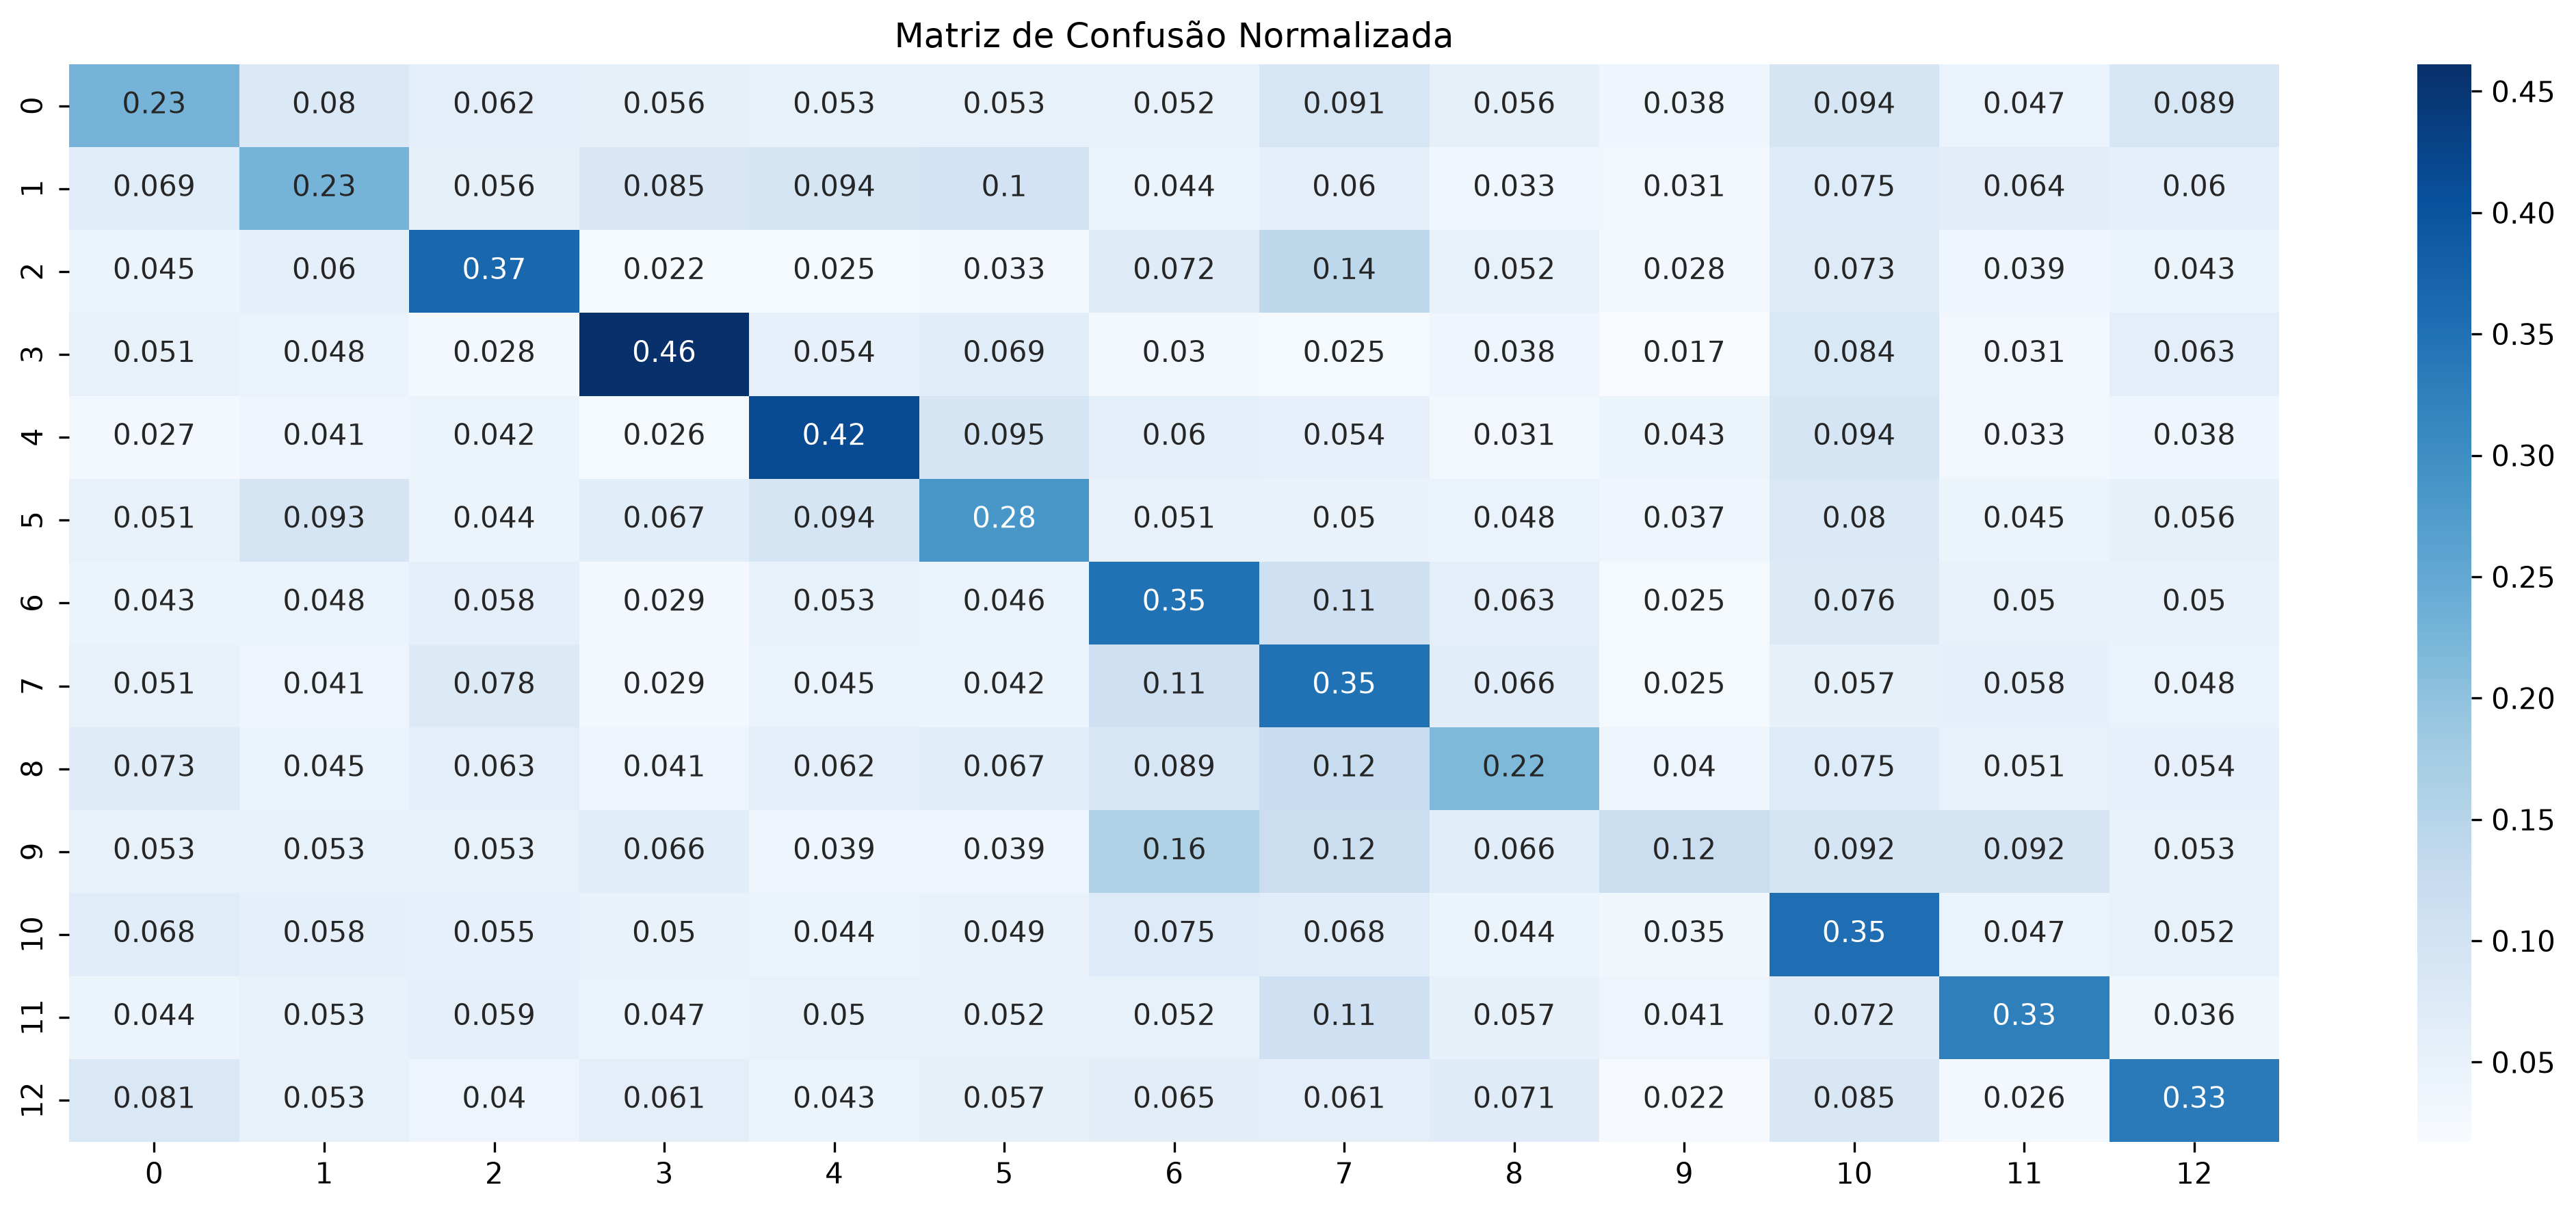

In [62]:
plt.figure(figsize=(14, 6), dpi=300)

sns.heatmap(confusion_matrix(y_te_enc, preds_no_emb_cluster, normalize="true"), annot=True, cmap="Blues")

plt.title("Matriz de Confusão Normalizada")
plt.tight_layout()


| Representação                |   Macro F1 |
| ---------------------------- | ---------: |
| TF-IDF                       |     0,2956 |
| TF-IDF + Embedding           |     0,2963 |
| TF-IDF + Cluster             |     0,2991 |
| TF-IDF + Embedding + Cluster | **0,3016** |



A inclusão das representações de embedding e clustering apresentou ganhos incrementais no desempenho. O modelo utilizando conjuntamente TF-IDF, embeddings e clusters obteve o maior Macro F1 (0,3016), superando o modelo baseado apenas em TF-IDF (0,2956).

A combinação de TF-IDF, embeddings e clusters K=25 apresentou o melhor desempenho entre as configurações avaliadas, com Macro F1 ≈ 0,302. Embora os ganhos individuais de embedding e cluster sejam pequenos, a configuração conjunta apresentou o maior desempenho e foi selecionada como modelo final.

In [91]:
import joblib

torch.save(
    model_25.state_dict(),
    "../artifacts/models/scia_mlp_k25.pt"
)

joblib.dump(
    le,
    "../artifacts/models/label_encoder.joblib"
)

['../artifacts/models/label_encoder.joblib']

In [97]:
sparse.save_npz(
    "../artifacts/analysis/X_test_25.npz",
    X_test_25
)

np.save(
    "../artifacts/analysis/y_test.npy",
    y_te_enc
)